In [ ]:
# =============================================================================
# CELL 1: INSTALL REQUIRED PACKAGES
# =============================================================================

!pip install faiss-cpu sentence-transformers transformers datasets scikit-learn torch pandas numpy matplotlib seaborn tqdm psutil gputil -q

print("✅ All packages installed successfully!")

import faiss
import sentence_transformers
import transformers
print(f"✅ FAISS version: {faiss.__version__}")
print(f"✅ Sentence Transformers version: {sentence_transformers.__version__}")
print(f"✅ Transformers version: {transformers.__version__}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 48.8 MB/s eta 0:00:00
✅ All packages installed successfully!
✅ FAISS version: 1.13.2
✅ Sentence Transformers version: 5.4.0
✅ Transformers version: 5.0.0


In [ ]:
# =============================================================================
# CELL 2: IMPORTS AND SETUP
# =============================================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel, AutoConfig
from sentence_transformers import SentenceTransformer
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report, precision_recall_fscore_support,
                             roc_curve, auc, precision_recall_curve, precision_score, recall_score)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import faiss
import warnings
import json
import os
import pickle
import random
import time
import psutil
from typing import List, Dict, Tuple, Optional
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from google.colab import files
import shutil
import zipfile
from datetime import datetime
import gc
import re

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Style settings for publication-quality plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

print("="*80)
print("OOD-AWARE RAG-BASED NETWORK ATTACK CLASSIFICATION SYSTEM")
print("ModernBERT with Prototype Classification + OOD Detection")
print("="*80)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
print(f"FAISS version: {faiss.__version__}")
print("="*80)

OOD-AWARE RAG-BASED NETWORK ATTACK CLASSIFICATION SYSTEM
ModernBERT with Prototype Classification + OOD Detection
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device: Tesla T4
FAISS version: 1.13.2


In [ ]:
# =============================================================================
# CELL 3: SYSTEM MONITORING CLASS
# =============================================================================

class SystemMonitor:
    """Monitor system resources during model execution"""

    def __init__(self):
        self.metrics = {
            'cpu_percent': [],
            'ram_used_gb': [],
            'gpu_used_gb': [],
            'gpu_percent': [],
            'timestamps': []
        }
        self.start_time = None

    def start(self):
        self.start_time = time.time()
        self._record_metrics()

    def _record_metrics(self):
        self.metrics['cpu_percent'].append(psutil.cpu_percent(interval=0.1))
        self.metrics['ram_used_gb'].append(psutil.virtual_memory().used / (1024**3))
        self.metrics['timestamps'].append(time.time() - self.start_time if self.start_time else 0)

        if torch.cuda.is_available():
            try:
                import GPUtil
                gpus = GPUtil.getGPUs()
                if gpus:
                    self.metrics['gpu_used_gb'].append(gpus[0].memoryUsed / 1024)
                    self.metrics['gpu_percent'].append(gpus[0].load * 100)
                else:
                    self.metrics['gpu_used_gb'].append(0)
                    self.metrics['gpu_percent'].append(0)
            except:
                self.metrics['gpu_used_gb'].append(0)
                self.metrics['gpu_percent'].append(0)
        else:
            self.metrics['gpu_used_gb'].append(0)
            self.metrics['gpu_percent'].append(0)

    def record(self):
        self._record_metrics()

    def get_summary(self):
        return {
            'avg_cpu_percent': np.mean(self.metrics['cpu_percent']),
            'max_cpu_percent': np.max(self.metrics['cpu_percent']),
            'avg_ram_gb': np.mean(self.metrics['ram_used_gb']),
            'max_ram_gb': np.max(self.metrics['ram_used_gb']),
            'avg_gpu_gb': np.mean(self.metrics['gpu_used_gb']) if self.metrics['gpu_used_gb'] else 0,
            'max_gpu_gb': np.max(self.metrics['gpu_used_gb']) if self.metrics['gpu_used_gb'] else 0,
            'avg_gpu_percent': np.mean(self.metrics['gpu_percent']) if self.metrics['gpu_percent'] else 0
        }

    def plot(self, save_path='system_metrics.png'):
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))

        times = self.metrics['timestamps']

        axes[0, 0].plot(times, self.metrics['cpu_percent'], 'b-', linewidth=1)
        axes[0, 0].set_xlabel('Time (s)')
        axes[0, 0].set_ylabel('CPU Usage (%)')
        axes[0, 0].set_title('CPU Usage Over Time')
        axes[0, 0].grid(True, alpha=0.3)

        axes[0, 1].plot(times, self.metrics['ram_used_gb'], 'g-', linewidth=1)
        axes[0, 1].set_xlabel('Time (s)')
        axes[0, 1].set_ylabel('RAM Usage (GB)')
        axes[0, 1].set_title('RAM Usage Over Time')
        axes[0, 1].grid(True, alpha=0.3)

        if any(self.metrics['gpu_used_gb']):
            axes[1, 0].plot(times, self.metrics['gpu_used_gb'], 'r-', linewidth=1)
            axes[1, 0].set_xlabel('Time (s)')
            axes[1, 0].set_ylabel('GPU Memory (GB)')
            axes[1, 0].set_title('GPU Memory Usage Over Time')
            axes[1, 0].grid(True, alpha=0.3)

            axes[1, 1].plot(times, self.metrics['gpu_percent'], 'm-', linewidth=1)
            axes[1, 1].set_xlabel('Time (s)')
            axes[1, 1].set_ylabel('GPU Usage (%)')
            axes[1, 1].set_title('GPU Usage Over Time')
            axes[1, 1].grid(True, alpha=0.3)
        else:
            axes[1, 0].text(0.5, 0.5, 'No GPU detected', ha='center', va='center', transform=axes[1, 0].transAxes)
            axes[1, 1].text(0.5, 0.5, 'No GPU detected', ha='center', va='center', transform=axes[1, 1].transAxes)

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

        return fig

In [ ]:
# =============================================================================
# CELL 4: EMBEDDING-ONLY MODEL LOADER (NO CLASSIFICATION HEAD)
# =============================================================================

class EmbeddingOnlyModel:
    """ModernBERT used ONLY as an embedding generator - no classification head"""

    def __init__(self, model, tokenizer, device):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.model.eval()

    def get_embeddings(self, texts: List[str], batch_size: int = 32) -> np.ndarray:
        """Extract normalized embeddings from text inputs"""
        embeddings = []

        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            inputs = self.tokenizer(batch, return_tensors="pt", truncation=True,
                                     max_length=512, padding=True).to(self.device)

            with torch.no_grad():
                outputs = self.model(**inputs)
                # Mean pooling over token dimension
                last_hidden = outputs.last_hidden_state
                attention_mask = inputs['attention_mask'].unsqueeze(-1)
                masked = last_hidden * attention_mask
                batch_embeddings = masked.sum(dim=1) / attention_mask.sum(dim=1)

            # L2 normalize
            batch_embeddings = batch_embeddings / torch.norm(batch_embeddings, dim=1, keepdim=True)
            embeddings.append(batch_embeddings.cpu().numpy())

        return np.vstack(embeddings)

class ModernBERTLoader:
    """Load ModernBERT model for embedding extraction only"""

    def __init__(self):
        self.models = {}
        self.tokenizers = {}
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def load_model(self, model_name, model_key):
        """Load a ModernBERT model for embedding extraction"""
        print(f"\n📥 Loading {model_key} from {model_name}...")

        try:
            start_time = time.time()
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = AutoModel.from_pretrained(model_name)
            model = model.to(self.device)
            model.eval()
            load_time = time.time() - start_time

            config = AutoConfig.from_pretrained(model_name)
            num_params = sum(p.numel() for p in model.parameters())

            self.models[model_key] = model
            self.tokenizers[model_key] = tokenizer

            print(f"   ✅ Loaded in {load_time:.2f}s")
            print(f"   Hidden size: {config.hidden_size}")
            print(f"   Parameters: {num_params:,}")
            print(f"   Device: {self.device}")

            return {
                'model': model,
                'tokenizer': tokenizer,
                'load_time': load_time,
                'hidden_size': config.hidden_size,
                'num_params': num_params,
                'device': str(self.device),
                'model_name': model_name
            }
        except Exception as e:
            print(f"   ❌ Failed to load {model_name}: {e}")
            return None

# Initialize model loader
model_loader = ModernBERTLoader()

print("\n" + "="*80)
print("LOADING MODERNBERT MODELS (EMBEDDING-ONLY)")
print("="*80)

# Load models
FINETUNED_MODEL_NAME = "ccaug/modernbert-IDS-Unknown"
BASE_MODEL_NAME = "answerdotai/ModernBERT-base"

finetuned_info = model_loader.load_model(FINETUNED_MODEL_NAME, 'finetuned')
base_info = model_loader.load_model(BASE_MODEL_NAME, 'base')

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)


LOADING MODERNBERT MODELS (EMBEDDING-ONLY)

📥 Loading finetuned from ccaug/modernbert-IDS-Unknown...


config.json:   0%|          | 0.00/892 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/598M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   ✅ Loaded in 10.15s
   Hidden size: 768
   Parameters: 149,014,272
   Device: cuda

MODEL COMPARISON


In [ ]:
# =============================================================================
# CELL 5: PROTOTYPE CLASSIFIER WITH OOD DETECTION
# =============================================================================

class PrototypeClassifier:
    """Classification using semantic prototypes with OOD detection"""

    def __init__(self, class_prototypes: Dict[str, np.ndarray],
                 similarity_threshold: float = 0.65):
        self.class_prototypes = class_prototypes
        self.similarity_threshold = similarity_threshold
        self.class_names = list(class_prototypes.keys())
        self.prototype_matrix = np.stack([self.class_prototypes[c] for c in self.class_names])

        # Normalize prototypes
        norms = np.linalg.norm(self.prototype_matrix, axis=1, keepdims=True)
        self.prototype_matrix = self.prototype_matrix / (norms + 1e-8)

    def detect_unknown(self, query_embedding: np.ndarray) -> Tuple[str, float]:
        """
        Detect unknown samples using prototype similarity threshold.
        Returns: (predicted_class, confidence_score)
        """
        query_embedding = query_embedding / (np.linalg.norm(query_embedding) + 1e-8)

        # Compute cosine similarity with all prototypes
        similarities = np.dot(self.prototype_matrix, query_embedding)
        # Clip to [-1, 1] and normalize to [0, 1]
        similarities = np.clip(similarities, -1.0, 1.0)
        similarities = (similarities + 1.0) / 2.0

        best_idx = np.argmax(similarities)
        best_score = similarities[best_idx]
        best_class = self.class_names[best_idx]

        if best_score < self.similarity_threshold:
            return "UNKNOWN_ATTACK", best_score

        return best_class, best_score

    def predict_batch(self, embeddings: np.ndarray) -> List[Tuple[str, float]]:
        """Predict for multiple embeddings"""
        results = []
        for emb in embeddings:
            results.append(self.detect_unknown(emb))
        return results

In [ ]:
# =============================================================================
# CELL 6: FAISS RETRIEVAL WITH UNCERTAINTY ESTIMATION
# =============================================================================

class FAISSRetriever:
    """Enhanced FAISS retrieval with uncertainty estimation"""

    def __init__(self, index: faiss.IndexFlatIP, documents: List[str],
                 k: int = 30):
        self.index = index
        self.documents = documents
        self.k = k

    def retrieve_with_uncertainty(self, query_embedding: np.ndarray) -> Tuple[List[str], List[float], float]:
        """
        Retrieve neighbors and compute uncertainty signal.
        Returns: (retrieved_docs, similarities, uncertainty_std)
        """
        query_embedding = query_embedding / (np.linalg.norm(query_embedding) + 1e-8)
        query_embedding = query_embedding.reshape(1, -1).astype('float32')

        similarities, indices = self.index.search(query_embedding, self.k)
        similarities = similarities[0]
        indices = indices[0]

        # Convert from inner product to cosine similarity (already normalized)
        similarities = (similarities + 1.0) / 2.0

        retrieved_docs = []
        valid_similarities = []

        for idx, sim in zip(indices, similarities):
            if idx >= 0 and idx < len(self.documents):
                retrieved_docs.append(self.documents[idx])
                valid_similarities.append(sim)

        valid_similarities = np.array(valid_similarities)

        # Uncertainty = std deviation of neighbor similarities
        uncertainty = np.std(valid_similarities) if len(valid_similarities) > 0 else 1.0

        return retrieved_docs, valid_similarities.tolist(), uncertainty

In [ ]:
# =============================================================================
# CELL 7: DECISION FUSION ENGINE
# =============================================================================

class DecisionFusion:
    """
    Combines prototype similarity, FAISS similarity, and FAISS uncertainty
    for robust OOD detection.
    """

    def __init__(self, proto_threshold: float = 0.65,
                 faiss_sim_threshold: float = 0.5,
                 uncertainty_threshold: float = 0.25):
        self.proto_threshold = proto_threshold
        self.faiss_sim_threshold = faiss_sim_threshold
        self.uncertainty_threshold = uncertainty_threshold

    def decide(self, proto_class: str, proto_score: float,
               faiss_similarities: List[float], faiss_uncertainty: float) -> str:
        """
        Fuse signals for final classification.
        Returns predicted class (or UNKNOWN_ATTACK)
        """
        avg_faiss_sim = np.mean(faiss_similarities) if faiss_similarities else 0.0

        # Rule 1: Low prototype + low local similarity → UNKNOWN
        if proto_score < self.proto_threshold and avg_faiss_sim < self.faiss_sim_threshold:
            return "UNKNOWN_ATTACK"

        # Rule 2: High neighbor variance → uncertainty → UNKNOWN
        if faiss_uncertainty > self.uncertainty_threshold:
            return "UNKNOWN_ATTACK"

        # Rule 3: Otherwise return prototype prediction
        return proto_class

In [ ]:
# =============================================================================
# CELL 8: THRESHOLD CALIBRATOR (Using REAL unknown data)
# =============================================================================

class ThresholdCalibrator:
    """Calibrates OOD thresholds using validation set statistics with REAL unknown data"""

    def __init__(self, prototype_classifier: PrototypeClassifier,
                 faiss_retriever: FAISSRetriever,
                 val_known_embeddings: np.ndarray,
                 val_unknown_embeddings: np.ndarray):
        self.prototype_classifier = prototype_classifier
        self.faiss_retriever = faiss_retriever
        self.val_known = val_known_embeddings
        self.val_unknown = val_unknown_embeddings

    def calibrate(self) -> Dict[str, float]:
        """Calculate optimal thresholds using percentile-based method on REAL data"""

        known_scores = []
        unknown_scores = []
        known_faiss_vars = []
        unknown_faiss_vars = []

        print("   Computing known sample statistics...")
        for emb in tqdm(self.val_known, desc="Known samples"):
            _, score = self.prototype_classifier.detect_unknown(emb)
            known_scores.append(score)
            _, _, uncertainty = self.faiss_retriever.retrieve_with_uncertainty(emb)
            known_faiss_vars.append(uncertainty)

        print("   Computing unknown sample statistics...")
        for emb in tqdm(self.val_unknown, desc="Unknown samples"):
            _, score = self.prototype_classifier.detect_unknown(emb)
            unknown_scores.append(score)
            _, _, uncertainty = self.faiss_retriever.retrieve_with_uncertainty(emb)
            unknown_faiss_vars.append(uncertainty)

        known_scores = np.array(known_scores)
        unknown_scores = np.array(unknown_scores)
        known_faiss_vars = np.array(known_faiss_vars)
        unknown_faiss_vars = np.array(unknown_faiss_vars)

        # Thresholds: use 10th percentile of known distribution for prototype
        proto_threshold = np.percentile(known_scores, 10)
        proto_threshold = max(0.45, min(0.75, proto_threshold))

        # FAISS uncertainty: use 90th percentile of known distribution
        uncertainty_threshold = np.percentile(known_faiss_vars, 90)
        uncertainty_threshold = max(0.15, min(0.35, uncertainty_threshold))

        faiss_sim_threshold = 0.5

        return {
            'proto_threshold': proto_threshold,
            'uncertainty_threshold': uncertainty_threshold,
            'faiss_sim_threshold': faiss_sim_threshold,
            'known_score_stats': {'mean': known_scores.mean(), 'std': known_scores.std()},
            'unknown_score_stats': {'mean': unknown_scores.mean(), 'std': unknown_scores.std()}
        }

In [ ]:
# =============================================================================
# CELL 9: COMPLETE OOD-AWARE CLASSIFIER
# =============================================================================

class OODAwareClassifier:
    """
    Complete OOD-aware classification pipeline combining:
    - Prototype similarity (global)
    - FAISS retrieval consistency (local)
    - Uncertainty estimation
    - Decision fusion
    """

    def __init__(self, embedder_model, tokenizer, device,
                 class_prototypes: Dict[str, np.ndarray],
                 faiss_index, retrieval_docs: List[str],
                 k: int = 30):

        self.embedder = EmbeddingOnlyModel(embedder_model, tokenizer, device)
        self.prototype_classifier = PrototypeClassifier(class_prototypes)
        self.faiss_retriever = FAISSRetriever(faiss_index, retrieval_docs, k=k)
        self.decision_fusion = DecisionFusion()
        self.calibrated = False

    def calibrate_thresholds(self, val_known_embeddings: np.ndarray,
                             val_unknown_embeddings: np.ndarray) -> Dict:
        """Calibrate thresholds using REAL validation embeddings"""
        calibrator = ThresholdCalibrator(
            self.prototype_classifier,
            self.faiss_retriever,
            val_known_embeddings,
            val_unknown_embeddings
        )
        thresholds = calibrator.calibrate()

        self.decision_fusion.proto_threshold = thresholds['proto_threshold']
        self.decision_fusion.uncertainty_threshold = thresholds['uncertainty_threshold']
        self.decision_fusion.faiss_sim_threshold = thresholds['faiss_sim_threshold']
        self.prototype_classifier.similarity_threshold = thresholds['proto_threshold']
        self.calibrated = True

        print(f"\n📊 Calibrated thresholds:")
        print(f"   Prototype threshold: {thresholds['proto_threshold']:.3f}")
        print(f"   Uncertainty threshold: {thresholds['uncertainty_threshold']:.3f}")
        print(f"   Known score stats: μ={thresholds['known_score_stats']['mean']:.3f}, σ={thresholds['known_score_stats']['std']:.3f}")
        print(f"   Unknown score stats: μ={thresholds['unknown_score_stats']['mean']:.3f}, σ={thresholds['unknown_score_stats']['std']:.3f}")

        return thresholds

    def classify_single(self, text: str) -> Tuple[str, float, Dict]:
        """Classify a single text sample"""
        embeddings = self.embedder.get_embeddings([text])
        query_emb = embeddings[0]

        proto_class, proto_score = self.prototype_classifier.detect_unknown(query_emb)
        retrieved_docs, faiss_sims, uncertainty = self.faiss_retriever.retrieve_with_uncertainty(query_emb)

        final_class = self.decision_fusion.decide(
            proto_class, proto_score, faiss_sims, uncertainty
        )

        debug_info = {
            'proto_class': proto_class,
            'proto_score': proto_score,
            'avg_faiss_sim': np.mean(faiss_sims) if faiss_sims else 0.0,
            'faiss_uncertainty': uncertainty,
            'final_class': final_class
        }

        return final_class, proto_score, debug_info

    def classify_batch(self, texts: List[str]) -> List[Tuple[str, float, Dict]]:
        """Classify multiple texts"""
        results = []
        for text in texts:
            results.append(self.classify_single(text))
        return results

In [ ]:
# =============================================================================
# CELL 10: BUILD ROBUST PROTOTYPES (NO SYNTHETIC DATA)
# =============================================================================

def build_robust_prototypes(train_texts: List[str], train_labels: List[str],
                            embedder_model, tokenizer, device) -> Dict[str, np.ndarray]:
    """Build class prototypes using the provided embedder model - NO synthetic generation"""

    embedder = EmbeddingOnlyModel(embedder_model, tokenizer, device)

    print("Generating training embeddings...")
    all_embeddings = embedder.get_embeddings(train_texts, batch_size=32)
    print(f"   Embedding shape: {all_embeddings.shape}")

    # Group by class
    class_embeddings = {}
    unique_labels = list(set(train_labels))

    for cls in unique_labels:
        mask = [l == cls for l in train_labels]
        class_embeddings[cls] = all_embeddings[mask]
        print(f"   Class {cls}: {len(class_embeddings[cls])} samples")

    # Initial prototypes = class means
    print("Computing initial prototypes...")
    prototypes = {}
    for cls, emb in class_embeddings.items():
        if len(emb) > 0:
            proto = emb.mean(axis=0)
            proto = proto / (np.linalg.norm(proto) + 1e-8)
            prototypes[cls] = proto

    return prototypes

In [ ]:
# =============================================================================
# CELL 11: FAISS INDEX BUILDER FOR MODERNBERT
# =============================================================================

class ModernBERTFAISSBuilder:
    """Build FAISS index using ModernBERT embeddings"""

    def __init__(self, embedder_model, tokenizer, device):
        self.embedder = EmbeddingOnlyModel(embedder_model, tokenizer, device)
        self.dimension = 768  # ModernBERT hidden size

    def build_index(self, texts: List[str], labels: List[str],
                    index_path: str = "./faiss_modernbert_index.bin",
                    metadata_path: str = "./faiss_modernbert_metadata.pkl"):
        """Build and save FAISS index with ModernBERT embeddings"""

        print(f"\n🔨 Building FAISS index with {len(texts)} documents...")
        print("   Using ModernBERT embeddings (768 dimensions)")

        print("🔄 Generating ModernBERT embeddings...")
        start_encode = time.time()
        embeddings = self.embedder.get_embeddings(texts, batch_size=32)
        encode_time = time.time() - start_encode
        embeddings = np.array(embeddings).astype("float32")
        print(f"   Encoding time: {encode_time:.2f}s")
        print(f"   Embedding shape: {embeddings.shape}")

        print("🔄 Normalizing embeddings...")
        faiss.normalize_L2(embeddings)

        print("🔄 Building FAISS index...")
        start_index = time.time()
        index = faiss.IndexFlatIP(self.dimension)
        index.add(embeddings)
        index_build_time = time.time() - start_index
        print(f"   Index build time: {index_build_time:.2f}s")

        # Test self-retrieval
        test_emb = embeddings[0:1]
        test_scores, test_idx = index.search(test_emb, 1)
        print(f"   Self-retrieval test: similarity = {test_scores[0][0]:.6f}")

        faiss.write_index(index, index_path)
        print(f"✅ FAISS index saved to {index_path}")

        with open(metadata_path, 'wb') as f:
            pickle.dump(labels, f)
        print(f"✅ Metadata saved to {metadata_path}")

        return index, labels

In [ ]:
# =============================================================================
# CELL 12: UPLOAD AND LOAD DATASETS
# =============================================================================

print("\n" + "="*80)
print("DATASET UPLOAD - 4 DATASETS REQUIRED")
print("="*80)
print("Please upload:")
print("  1. training_dataset.csv (contains 9 known attack types)")
print("  2. master_security_dataset.csv (for RAG index)")
print("  3. sample_security_dataset.csv (for testing unknown attacks)")
print("  4. UNSW_NB15_testing-set.csv (optional test dataset)")
print("="*80)

os.makedirs('./datasets', exist_ok=True)

# Upload training dataset
print("\n📁 Upload training_dataset.csv")
uploaded_train = files.upload()
for filename in uploaded_train.keys():
    dest_path = f'./datasets/{filename}'
    if os.path.exists(filename):
        shutil.move(filename, dest_path)
    TRAINING_PATH = dest_path
    print(f"✅ Training dataset saved: {TRAINING_PATH}")

# Upload master dataset
print("\n📁 Upload master_security_dataset.csv")
uploaded_master = files.upload()
for filename in uploaded_master.keys():
    dest_path = f'./datasets/{filename}'
    if os.path.exists(filename):
        shutil.move(filename, dest_path)
    MASTER_PATH = dest_path
    print(f"✅ Master dataset saved: {MASTER_PATH}")

# Upload sample dataset
print("\n📁 Upload sample_security_dataset.csv")
uploaded_sample = files.upload()
for filename in uploaded_sample.keys():
    dest_path = f'./datasets/{filename}'
    if os.path.exists(filename):
        shutil.move(filename, dest_path)
    SAMPLE_PATH = dest_path
    print(f"✅ Sample dataset saved: {SAMPLE_PATH}")

# Upload test dataset (optional)
print("\n📁 Upload UNSW_NB15_testing-set.csv (optional)")
uploaded_test = files.upload()
TEST_PATH = None
for filename in uploaded_test.keys():
    dest_path = f'./datasets/{filename}'
    if os.path.exists(filename):
        shutil.move(filename, dest_path)
    TEST_PATH = dest_path
    print(f"✅ Test dataset saved: {TEST_PATH}")

# Load datasets
print("\n" + "="*60)
print("LOADING DATASETS")
print("="*60)

df_train = pd.read_csv(TRAINING_PATH)
print(f"\n📊 Training dataset: {len(df_train)} samples")
print(f"   Columns: {df_train.columns.tolist()}")
print(f"   Attack types: {df_train['Attack Type'].unique().tolist()}")

df_master = pd.read_csv(MASTER_PATH)
print(f"\n📊 Master dataset: {len(df_master)} samples")
print(f"   Columns: {df_master.columns.tolist()}")

df_sample = pd.read_csv(SAMPLE_PATH)
print(f"\n📊 Sample dataset: {len(df_sample)} samples")
print(f"   Attack types: {df_sample['Attack Type'].unique().tolist()}")

if TEST_PATH:
    df_test = pd.read_csv(TEST_PATH)
    print(f"\n📊 Test dataset (UNSW-NB15): {len(df_test)} samples")
    print(f"   Columns: {df_test.columns.tolist()[:10]}...")
else:
    df_test = None
    print("\n⚠️ No additional test dataset provided")


DATASET UPLOAD - 4 DATASETS REQUIRED
Please upload:
  1. training_dataset.csv (contains 9 known attack types)
  2. master_security_dataset.csv (for RAG index)
  3. sample_security_dataset.csv (for testing unknown attacks)
  4. UNSW_NB15_testing-set.csv (optional test dataset)

📁 Upload training_dataset.csv


Saving training_dataset.csv to training_dataset.csv
✅ Training dataset saved: ./datasets/training_dataset.csv

📁 Upload master_security_dataset.csv


Saving master_security_dataset.csv to master_security_dataset.csv
✅ Master dataset saved: ./datasets/master_security_dataset.csv

📁 Upload sample_security_dataset.csv


Saving sample_security_dataset.csv to sample_security_dataset.csv
✅ Sample dataset saved: ./datasets/sample_security_dataset.csv

📁 Upload UNSW_NB15_testing-set.csv (optional)


Saving UNSW_NB15_testing-set.csv to UNSW_NB15_testing-set.csv
✅ Test dataset saved: ./datasets/UNSW_NB15_testing-set.csv

LOADING DATASETS

📊 Training dataset: 4500 samples
   Columns: ['Log', 'Attack Type']
   Attack types: ['DNS Fast-Flux', 'DoS', 'DoS + Brute-Force', 'FTP Brute-Force / Data Exfiltration', 'HTTP C2', 'ICMP Flood', 'IRC C2', 'P2P / UDP Scan', 'Spam']

📊 Master dataset: 356734 samples
   Columns: ['Log', 'Attack Type', 'Source']

📊 Sample dataset: 807 samples
   Attack types: ['Anomaly', 'Benign', 'Bot', 'Brute_Force', 'DDoS', 'DoS', 'Dos Attacks-Goldeneye', 'Portscan', 'Web_Attack']

📊 Test dataset (UNSW-NB15): 82332 samples
   Columns: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate']...


In [ ]:
# =============================================================================
# CELL 13: DATA PREPARATION AND LABEL MAPPING
# =============================================================================

print("\n" + "="*80)
print("DATA PREPARATION")
print("="*80)

KNOWN_ATTACKS = [
    'DNS Fast-Flux', 'DoS', 'DoS + Brute-Force',
    'FTP Brute-Force / Data Exfiltration', 'HTTP C2',
    'ICMP Flood', 'IRC C2', 'P2P / UDP Scan', 'Spam'
]

print(f"\n📋 Known attacks ({len(KNOWN_ATTACKS)}):")
for i, attack in enumerate(KNOWN_ATTACKS, 1):
    print(f"   {i}. {attack}")

# Create label mapping
label_mapping = {attack: idx for idx, attack in enumerate(KNOWN_ATTACKS)}
label_mapping['UNKNOWN_ATTACK'] = len(KNOWN_ATTACKS)
id_to_label = {v: k for k, v in label_mapping.items()}

print(f"\n📋 Label mapping ({len(label_mapping)} classes):")
for label, idx in label_mapping.items():
    print(f"   {idx}: {label}")

# Analyze sample dataset
df_sample['Is Known'] = df_sample['Attack Type'].apply(lambda x: x in KNOWN_ATTACKS)
df_sample_known = df_sample[df_sample['Is Known']].copy()
df_sample_unknown = df_sample[~df_sample['Is Known']].copy()

print(f"\n📊 Sample dataset breakdown:")
print(f"   Known attacks in sample: {len(df_sample_known)} samples")
print(f"   Unknown attacks in sample: {len(df_sample_unknown)} samples")

if len(df_sample_unknown) > 0:
    print(f"\n   Unknown attack types found:")
    for attack_type in df_sample_unknown['Attack Type'].unique():
        count = len(df_sample_unknown[df_sample_unknown['Attack Type'] == attack_type])
        print(f"     - {attack_type}: {count} samples")


DATA PREPARATION

📋 Known attacks (9):
   1. DNS Fast-Flux
   2. DoS
   3. DoS + Brute-Force
   4. FTP Brute-Force / Data Exfiltration
   5. HTTP C2
   6. ICMP Flood
   7. IRC C2
   8. P2P / UDP Scan
   9. Spam

📋 Label mapping (10 classes):
   0: DNS Fast-Flux
   1: DoS
   2: DoS + Brute-Force
   3: FTP Brute-Force / Data Exfiltration
   4: HTTP C2
   5: ICMP Flood
   6: IRC C2
   7: P2P / UDP Scan
   8: Spam
   9: UNKNOWN_ATTACK

📊 Sample dataset breakdown:
   Known attacks in sample: 100 samples
   Unknown attacks in sample: 707 samples

   Unknown attack types found:
     - Anomaly: 100 samples
     - Benign: 100 samples
     - Bot: 100 samples
     - Brute_Force: 100 samples
     - DDoS: 100 samples
     - Dos Attacks-Goldeneye: 100 samples
     - Portscan: 7 samples
     - Web_Attack: 100 samples


In [ ]:
# =============================================================================
# CELL 14: PREPROCESS TEST DATASETS
# =============================================================================

print("\n" + "="*80)
print("PREPROCESSING TEST DATASETS")
print("="*80)

def preprocess_unsw_row(row):
    """Convert UNSW-NB15 row to log string format"""
    if 'Log' in row.index:
        return str(row['Log'])

    log_parts = []
    for col in ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts',
                 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload']:
        if col in row and pd.notna(row[col]):
            val = row[col]
            if isinstance(val, float):
                log_parts.append(f"{col}: {val:.6f}")
            else:
                log_parts.append(f"{col}: {val}")

    if 'attack_cat' in row and pd.notna(row['attack_cat']):
        log_parts.append(f"attack_cat: {row['attack_cat']}")
    if 'label' in row and pd.notna(row['label']):
        log_parts.append(f"label: {row['label']}")

    return " | ".join(log_parts) if log_parts else str(row)

# Map UNSW attack categories to known labels
UNSW_TO_KNOWN_MAPPING = {
    'DoS': 'DoS',
    'DDoS': 'DoS',
    'Fuzzers': 'DoS + Brute-Force',
    'Exploits': 'HTTP C2',
    'Generic': 'Spam',
    'Reconnaissance': 'P2P / UDP Scan',
    'Analysis': 'DNS Fast-Flux',
    'Backdoor': 'IRC C2',
    'Shellcode': 'FTP Brute-Force / Data Exfiltration',
    'Worms': 'Spam',
    'Normal': 'Benign',
}

# Build complete test set
test_texts = []
test_labels_original = []
test_labels = []
test_source = []

# 1. Add known attacks from training dataset (balanced - 50 per class)
print("\n📊 Adding known attacks from TRAINING dataset...")
for attack in KNOWN_ATTACKS:
    attack_samples = df_train[df_train['Attack Type'] == attack]
    n_samples = min(50, len(attack_samples))
    sampled = attack_samples.sample(n=n_samples, random_state=42)
    for idx, row in sampled.iterrows():
        test_texts.append(row['Log'])
        test_labels_original.append(row['Attack Type'])
        test_labels.append(label_mapping[row['Attack Type']])
        test_source.append('training_known')
    print(f"   {attack}: {n_samples} samples")

# 2. Add unknown attacks from sample dataset (max 150 samples)
print("\n📊 Adding attacks from SAMPLE dataset...")
unknown_samples = df_sample_unknown.sample(n=min(150, len(df_sample_unknown)), random_state=42)
for idx, row in unknown_samples.iterrows():
    test_texts.append(row['Log'])
    test_labels_original.append(row['Attack Type'])
    test_labels.append(label_mapping['UNKNOWN_ATTACK'])
    test_source.append('sample')
print(f"   UNKNOWN samples: {len(unknown_samples)}")

# 3. Add UNSW test data with mapping (max 200 samples)
if df_test is not None:
    print("\n📊 Adding UNSW-NB15 test data...")

    if 'Log' not in df_test.columns:
        df_test['Log'] = df_test.apply(preprocess_unsw_row, axis=1)

    attack_col = None
    for col in ['attack_cat', 'Attack Type', 'label']:
        if col in df_test.columns:
            attack_col = col
            break

    if attack_col:
        df_test['Mapped_Attack'] = df_test[attack_col].map(UNSW_TO_KNOWN_MAPPING)
        df_test['Mapped_Attack'] = df_test['Mapped_Attack'].fillna('UNKNOWN_ATTACK')

        sampled_unsw = df_test.sample(n=min(200, len(df_test)), random_state=42)

        for idx, row in sampled_unsw.iterrows():
            test_texts.append(row['Log'])
            mapped_attack = row['Mapped_Attack']
            test_labels_original.append(mapped_attack)
            test_source.append('unsw')

            if mapped_attack in KNOWN_ATTACKS:
                test_labels.append(label_mapping[mapped_attack])
            else:
                test_labels.append(label_mapping['UNKNOWN_ATTACK'])

        print(f"   Added {len(sampled_unsw)} UNSW samples")

print(f"\n📊 FINAL TEST SET SUMMARY:")
print(f"   Total samples: {len(test_texts)}")
print(f"   Known samples: {sum(1 for l in test_labels if l != label_mapping['UNKNOWN_ATTACK'])}")
print(f"   Unknown samples: {sum(1 for l in test_labels if l == label_mapping['UNKNOWN_ATTACK'])}")

print(f"\n   Class distribution:")
label_counts = Counter(test_labels)
for label_id, count in sorted(label_counts.items()):
    class_name = id_to_label[label_id]
    print(f"     {class_name}: {count} samples")


PREPROCESSING TEST DATASETS

📊 Adding known attacks from TRAINING dataset...
   DNS Fast-Flux: 50 samples
   DoS: 50 samples
   DoS + Brute-Force: 50 samples
   FTP Brute-Force / Data Exfiltration: 50 samples
   HTTP C2: 50 samples
   ICMP Flood: 50 samples
   IRC C2: 50 samples
   P2P / UDP Scan: 50 samples
   Spam: 50 samples

📊 Adding attacks from SAMPLE dataset...
   UNKNOWN samples: 150

📊 Adding UNSW-NB15 test data...
   Added 200 UNSW samples

📊 FINAL TEST SET SUMMARY:
   Total samples: 800
   Known samples: 552
   Unknown samples: 248

   Class distribution:
     DNS Fast-Flux: 53 samples
     DoS: 58 samples
     DoS + Brute-Force: 60 samples
     FTP Brute-Force / Data Exfiltration: 51 samples
     HTTP C2: 77 samples
     ICMP Flood: 50 samples
     IRC C2: 50 samples
     P2P / UDP Scan: 55 samples
     Spam: 98 samples
     UNKNOWN_ATTACK: 248 samples


In [ ]:
# =============================================================================
# CELL 15: BUILD FAISS INDEX FOR RETRIEVAL
# =============================================================================

print("\n" + "="*80)
print("BUILDING FAISS INDEX FOR RETRIEVAL")
print("="*80)

rag_df = df_train[df_train['Attack Type'].isin(KNOWN_ATTACKS)].copy()
print(f"Using {len(rag_df)} training samples for RAG index")
print(f"Attack types in index: {rag_df['Attack Type'].unique().tolist()}")


BUILDING FAISS INDEX FOR RETRIEVAL
Using 4500 training samples for RAG index
Attack types in index: ['DNS Fast-Flux', 'DoS', 'DoS + Brute-Force', 'FTP Brute-Force / Data Exfiltration', 'HTTP C2', 'ICMP Flood', 'IRC C2', 'P2P / UDP Scan', 'Spam']


In [ ]:
# =============================================================================
# CELL 16: EVALUATION FUNCTION FOR OOD CLASSIFIER
# =============================================================================

def evaluate_ood_classifier(classifier: OODAwareClassifier, test_texts: List[str],
                            test_labels: List[int], label_mapping: Dict,
                            id_to_label: Dict, verbose: bool = True) -> Dict:
    """Evaluate the OOD-aware classifier and return metrics"""

    predictions = []
    pred_labels = []
    confidences = []
    unknown_id = label_mapping.get('UNKNOWN_ATTACK', len(label_mapping) - 1)

    for i, text in enumerate(tqdm(test_texts, desc="Classifying")):
        pred_class, score, debug = classifier.classify_single(text)

        if pred_class == "UNKNOWN_ATTACK":
            pred_id = unknown_id
        else:
            pred_id = label_mapping.get(pred_class, unknown_id)

        predictions.append(pred_class)
        pred_labels.append(pred_id)
        confidences.append(score)

    # Calculate metrics
    accuracy = accuracy_score(test_labels, pred_labels)

    # Known vs unknown metrics
    known_mask = [l != unknown_id for l in test_labels]
    unknown_mask = [l == unknown_id for l in test_labels]

    known_accuracy = accuracy_score(
        [test_labels[i] for i in range(len(test_labels)) if known_mask[i]],
        [pred_labels[i] for i in range(len(pred_labels)) if known_mask[i]]
    ) if any(known_mask) else 0

    unknown_accuracy = accuracy_score(
        [test_labels[i] for i in range(len(test_labels)) if unknown_mask[i]],
        [pred_labels[i] for i in range(len(pred_labels)) if unknown_mask[i]]
    ) if any(unknown_mask) else 0

    f1_macro = f1_score(test_labels, pred_labels, average='macro', zero_division=0)
    f1_weighted = f1_score(test_labels, pred_labels, average='weighted', zero_division=0)
    precision_macro = precision_score(test_labels, pred_labels, average='macro', zero_division=0)
    recall_macro = recall_score(test_labels, pred_labels, average='macro', zero_division=0)

    if verbose:
        print(f"\n📊 OOD-Aware Classifier Results:")
        print(f"   Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
        print(f"   Known Attack Accuracy: {known_accuracy:.4f} ({known_accuracy*100:.2f}%)")
        print(f"   Unknown Attack Accuracy: {unknown_accuracy:.4f} ({unknown_accuracy*100:.2f}%)")
        print(f"   F1 Macro: {f1_macro:.4f}")
        print(f"   F1 Weighted: {f1_weighted:.4f}")
        print(f"   Precision Macro: {precision_macro:.4f}")
        print(f"   Recall Macro: {recall_macro:.4f}")

    return {
        'predictions': predictions,
        'pred_labels': pred_labels,
        'accuracy': accuracy,
        'known_accuracy': known_accuracy,
        'unknown_accuracy': unknown_accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'confidences': confidences
    }

In [ ]:
# =============================================================================
# CELL 17: EVALUATE FINETUNED MODEL WITH OOD-AWARE CLASSIFIER (USING REAL UNKNOWN DATA)
# =============================================================================

print("\n" + "="*80)
print("EVALUATING FINETUNED MODERNBERT WITH OOD-AWARE CLASSIFIER")
print("="*80)

# Build prototypes from training data using ModernBERT embeddings
train_texts = df_train['Log'].tolist()
train_labels = df_train['Attack Type'].tolist()

prototypes = build_robust_prototypes(
    train_texts, train_labels,
    model_loader.models['finetuned'],
    model_loader.tokenizers['finetuned'],
    model_loader.device
)

# Build FAISS index using ModernBERT embeddings
modernbert_index_builder = ModernBERTFAISSBuilder(
    model_loader.models['finetuned'],
    model_loader.tokenizers['finetuned'],
    model_loader.device
)

MODERNBERT_INDEX_PATH = "./faiss_modernbert_index.bin"
MODERNBERT_METADATA_PATH = "./faiss_modernbert_metadata.pkl"

modernbert_index, modernbert_labels = modernbert_index_builder.build_index(
    texts=rag_df['Log'].tolist(),
    labels=rag_df['Attack Type'].tolist(),
    index_path=MODERNBERT_INDEX_PATH,
    metadata_path=MODERNBERT_METADATA_PATH
)

# Create OOD-aware classifier
ood_classifier = OODAwareClassifier(
    embedder_model=model_loader.models['finetuned'],
    tokenizer=model_loader.tokenizers['finetuned'],
    device=model_loader.device,
    class_prototypes=prototypes,
    faiss_index=modernbert_index,
    retrieval_docs=rag_df['Log'].tolist(),
    k=30
)

# Create validation split for calibration (using REAL unknown data)
print("\n" + "="*50)
print("CREATING VALIDATION SETS WITH REAL UNKNOWN DATA")
print("="*50)

# Split training data into train/val for known samples
train_texts_for_val, val_texts_known, train_labels_for_val, val_labels_known = train_test_split(
    train_texts, train_labels, test_size=0.2, random_state=42
)

# Extract REAL unknown embeddings from sample dataset
print("\n📊 Extracting REAL unknown embeddings from sample dataset...")
sample_unknown_texts = df_sample_unknown['Log'].tolist()
sample_unknown_texts = sample_unknown_texts[:200]  # Use up to 200 samples

# Get embeddings for real unknown attacks
val_unknown_embeddings = ood_classifier.embedder.get_embeddings(sample_unknown_texts)

# Get embeddings for known validation samples
val_known_embeddings = ood_classifier.embedder.get_embeddings(val_texts_known[:200])

print(f"   Validation known samples: {len(val_known_embeddings)}")
print(f"   Validation unknown samples (real): {len(val_unknown_embeddings)}")
print(f"   Unknown attack types in validation: {df_sample_unknown['Attack Type'].unique().tolist()[:5]}...")

# Calibrate thresholds using REAL unknown data
thresholds = ood_classifier.calibrate_thresholds(val_known_embeddings, val_unknown_embeddings)

# Evaluate
finetuned_ood_results = evaluate_ood_classifier(
    ood_classifier, test_texts, test_labels,
    label_mapping, id_to_label, verbose=True
)


EVALUATING FINETUNED MODERNBERT WITH OOD-AWARE CLASSIFIER
Generating training embeddings...


W0424 14:04:36.840000 1241 torch/_inductor/utils.py:1679] [1/0_1] Not enough SMs to use max_autotune_gemm mode


   Embedding shape: (4500, 768)
   Class ICMP Flood: 500 samples
   Class DoS + Brute-Force: 500 samples
   Class P2P / UDP Scan: 500 samples
   Class IRC C2: 500 samples
   Class DNS Fast-Flux: 500 samples
   Class DoS: 500 samples
   Class FTP Brute-Force / Data Exfiltration: 500 samples
   Class HTTP C2: 500 samples
   Class Spam: 500 samples
Computing initial prototypes...

🔨 Building FAISS index with 4500 documents...
   Using ModernBERT embeddings (768 dimensions)
🔄 Generating ModernBERT embeddings...
   Encoding time: 31.70s
   Embedding shape: (4500, 768)
🔄 Normalizing embeddings...
🔄 Building FAISS index...
   Index build time: 0.02s
   Self-retrieval test: similarity = 1.000000
✅ FAISS index saved to ./faiss_modernbert_index.bin
✅ Metadata saved to ./faiss_modernbert_metadata.pkl

CREATING VALIDATION SETS WITH REAL UNKNOWN DATA

📊 Extracting REAL unknown embeddings from sample dataset...
   Validation known samples: 200
   Validation unknown samples (real): 200
   Unknown att

Known samples: 100%|██████████| 200/200 [00:00<00:00, 1042.53it/s]


   Computing unknown sample statistics...


Unknown samples: 100%|██████████| 200/200 [00:00<00:00, 1028.26it/s]



📊 Calibrated thresholds:
   Prototype threshold: 0.750
   Uncertainty threshold: 0.150
   Known score stats: μ=0.957, σ=0.019
   Unknown score stats: μ=0.667, σ=0.013


Classifying: 100%|██████████| 800/800 [00:25<00:00, 31.43it/s]


📊 OOD-Aware Classifier Results:
   Overall Accuracy: 0.7350 (73.50%)
   Known Attack Accuracy: 0.6159 (61.59%)
   Unknown Attack Accuracy: 1.0000 (100.00%)
   F1 Macro: 0.7019
   F1 Weighted: 0.7237
   Precision Macro: 0.7703
   Recall Macro: 0.6758


In [ ]:
# =============================================================================
# CELL 18: EVALUATE BASE MODEL WITH OOD-AWARE CLASSIFIER (USING REAL UNKNOWN DATA)
# =============================================================================

print("\n" + "="*80)
print("EVALUATING BASE MODERNBERT WITH OOD-AWARE CLASSIFIER")
print("="*80)

# Build prototypes from training data for base model
base_embedder = EmbeddingOnlyModel(
    model_loader.models['base'],
    model_loader.tokenizers['base'],
    model_loader.device
)

print("Generating training embeddings for base model...")
base_all_embeddings = base_embedder.get_embeddings(train_texts, batch_size=32)

# Get unique labels from training
train_labels_unique = list(set(train_labels))

base_prototypes = {}
for cls in train_labels_unique:
    mask = [l == cls for l in train_labels]
    cls_emb = base_all_embeddings[mask]
    if len(cls_emb) > 0:
        proto = cls_emb.mean(axis=0)
        proto = proto / (np.linalg.norm(proto) + 1e-8)
        base_prototypes[cls] = proto

print(f"Built {len(base_prototypes)} base prototypes")

# Build FAISS index for base model
print("\n" + "="*50)
print("BUILDING FAISS INDEX FOR BASE MODEL")
print("="*50)

class BaseModelFAISSBuilder:
    """Build FAISS index using Base ModernBERT embeddings"""

    def __init__(self, embedder_model, tokenizer, device):
        self.embedder = EmbeddingOnlyModel(embedder_model, tokenizer, device)
        self.dimension = 768  # ModernBERT hidden size

    def build_index(self, texts: List[str], labels: List[str],
                    index_path: str = "./faiss_base_index.bin",
                    metadata_path: str = "./faiss_base_metadata.pkl"):

        print(f"\n🔨 Building FAISS index with {len(texts)} documents...")
        print("   Using Base ModernBERT embeddings (768 dimensions)")

        print("🔄 Generating Base ModernBERT embeddings...")
        start_encode = time.time()
        embeddings = self.embedder.get_embeddings(texts, batch_size=32)
        encode_time = time.time() - start_encode
        embeddings = np.array(embeddings).astype("float32")
        print(f"   Encoding time: {encode_time:.2f}s")
        print(f"   Embedding shape: {embeddings.shape}")

        print("🔄 Normalizing embeddings...")
        faiss.normalize_L2(embeddings)

        print("🔄 Building FAISS index...")
        start_index = time.time()
        index = faiss.IndexFlatIP(self.dimension)
        index.add(embeddings)
        index_build_time = time.time() - start_index
        print(f"   Index build time: {index_build_time:.2f}s")

        test_emb = embeddings[0:1]
        test_scores, test_idx = index.search(test_emb, 1)
        print(f"   Self-retrieval test: similarity = {test_scores[0][0]:.6f}")

        faiss.write_index(index, index_path)
        print(f"✅ FAISS index saved to {index_path}")

        with open(metadata_path, 'wb') as f:
            pickle.dump(labels, f)
        print(f"✅ Metadata saved to {metadata_path}")

        return index, labels

# Build FAISS index for base model
base_faiss_builder = BaseModelFAISSBuilder(
    model_loader.models['base'],
    model_loader.tokenizers['base'],
    model_loader.device
)

BASE_INDEX_PATH = "./faiss_base_index.bin"
BASE_METADATA_PATH = "./faiss_base_metadata.pkl"

base_index, base_labels = base_faiss_builder.build_index(
    texts=rag_df['Log'].tolist(),
    labels=rag_df['Attack Type'].tolist(),
    index_path=BASE_INDEX_PATH,
    metadata_path=BASE_METADATA_PATH
)

# Create OOD-aware classifier for base model
base_ood_classifier = OODAwareClassifier(
    embedder_model=model_loader.models['base'],
    tokenizer=model_loader.tokenizers['base'],
    device=model_loader.device,
    class_prototypes=base_prototypes,
    faiss_index=base_index,
    retrieval_docs=rag_df['Log'].tolist(),
    k=30
)

# Generate validation embeddings for base model using REAL unknown data
print("\n📊 Generating validation embeddings for base model calibration...")
base_val_known_embeddings = base_embedder.get_embeddings(val_texts_known[:200])
base_val_unknown_embeddings = base_embedder.get_embeddings(sample_unknown_texts[:200])

print(f"   Validation known samples: {len(base_val_known_embeddings)}")
print(f"   Validation unknown samples (real): {len(base_val_unknown_embeddings)}")

# Calibrate thresholds
base_thresholds = base_ood_classifier.calibrate_thresholds(
    base_val_known_embeddings, base_val_unknown_embeddings
)

# Evaluate
base_ood_results = evaluate_ood_classifier(
    base_ood_classifier, test_texts, test_labels,
    label_mapping, id_to_label, verbose=True
)


EVALUATING BASE MODERNBERT WITH OOD-AWARE CLASSIFIER
Generating training embeddings for base model...
Built 9 base prototypes

BUILDING FAISS INDEX FOR BASE MODEL

🔨 Building FAISS index with 4500 documents...
   Using Base ModernBERT embeddings (768 dimensions)
🔄 Generating Base ModernBERT embeddings...
   Encoding time: 32.65s
   Embedding shape: (4500, 768)
🔄 Normalizing embeddings...
🔄 Building FAISS index...
   Index build time: 0.00s
   Self-retrieval test: similarity = 1.000000
✅ FAISS index saved to ./faiss_base_index.bin
✅ Metadata saved to ./faiss_base_metadata.pkl

📊 Generating validation embeddings for base model calibration...
   Validation known samples: 200
   Validation unknown samples (real): 200
   Computing known sample statistics...


Known samples: 100%|██████████| 200/200 [00:00<00:00, 1088.82it/s]


   Computing unknown sample statistics...


Unknown samples: 100%|██████████| 200/200 [00:00<00:00, 1315.72it/s]



📊 Calibrated thresholds:
   Prototype threshold: 0.750
   Uncertainty threshold: 0.150
   Known score stats: μ=0.995, σ=0.004
   Unknown score stats: μ=0.945, σ=0.008


Classifying: 100%|██████████| 800/800 [00:24<00:00, 32.90it/s]


📊 OOD-Aware Classifier Results:
   Overall Accuracy: 0.3675 (36.75%)
   Known Attack Accuracy: 0.5326 (53.26%)
   Unknown Attack Accuracy: 0.0000 (0.00%)
   F1 Macro: 0.4405
   F1 Weighted: 0.3456
   Precision Macro: 0.4762
   Recall Macro: 0.4950


In [ ]:
# =============================================================================
# CELL 19: TRADITIONAL MODELS FOR COMPARISON
# =============================================================================

print("\n" + "="*80)
print("TRAINING TRADITIONAL MODELS")
print("="*80)

# Note: Traditional models cannot detect UNKNOWN attacks, so we evaluate only on knowns
train_texts_traditional = df_train['Log'].tolist()
train_labels_traditional = [label_mapping[t] for t in df_train['Attack Type'].tolist()]

# Filter test to only known samples for traditional models
known_test_indices = [i for i, l in enumerate(test_labels) if l != label_mapping['UNKNOWN_ATTACK']]
test_texts_known = [test_texts[i] for i in known_test_indices]
test_labels_known = [test_labels[i] for i in known_test_indices]

print(f"Training samples: {len(train_texts_traditional)}")
print(f"Test samples (known only): {len(test_texts_known)}")

# TF-IDF Vectorization
print("\n🔄 Vectorizing with TF-IDF...")
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(train_texts_traditional)
X_test_tfidf = tfidf.transform(test_texts_known)
print(f"   Features: {X_train_tfidf.shape[1]}")

traditional_models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='linear', probability=True, random_state=42)
}

traditional_results = {}
traditional_predictions = {}

for name, model in traditional_models.items():
    print(f"\n📊 Training {name}...")
    model.fit(X_train_tfidf, train_labels_traditional)

    start_infer = time.time()
    preds = model.predict(X_test_tfidf)
    inference_time = time.time() - start_infer

    traditional_predictions[name] = preds

    accuracy = accuracy_score(test_labels_known, preds)
    f1_macro = f1_score(test_labels_known, preds, average='macro', zero_division=0)

    traditional_results[name] = {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'inference_time': inference_time
    }

    print(f"   Accuracy: {accuracy:.4f}, F1 Macro: {f1_macro:.4f}")


TRAINING TRADITIONAL MODELS
Training samples: 4500
Test samples (known only): 552

🔄 Vectorizing with TF-IDF...
   Features: 5000

📊 Training Random Forest...
   Accuracy: 0.8152, F1 Macro: 0.8547

📊 Training Logistic Regression...
   Accuracy: 0.8007, F1 Macro: 0.8375

📊 Training SVM...
   Accuracy: 0.7989, F1 Macro: 0.8319


In [ ]:
# =============================================================================
# CELL 20: RESULTS COMPARISON
# =============================================================================

print("\n" + "="*80)
print("COMPLETE RESULTS COMPARISON")
print("="*80)

all_results = []

# OOD Finetuned Model
all_results.append({
    'Model': 'OOD Finetuned ModernBERT',
    'Accuracy': finetuned_ood_results['accuracy'],
    'Known Acc': finetuned_ood_results['known_accuracy'],
    'Unknown Acc': finetuned_ood_results['unknown_accuracy'],
    'F1 Macro': finetuned_ood_results['f1_macro']
})

# OOD Base Model
all_results.append({
    'Model': 'OOD Base ModernBERT',
    'Accuracy': base_ood_results['accuracy'],
    'Known Acc': base_ood_results['known_accuracy'],
    'Unknown Acc': base_ood_results['unknown_accuracy'],
    'F1 Macro': base_ood_results['f1_macro']
})

# Traditional models
for name, res in traditional_results.items():
    all_results.append({
        'Model': name,
        'Accuracy': res['accuracy'],
        'Known Acc': res['accuracy'],
        'Unknown Acc': 0.0,
        'F1 Macro': res['f1_macro']
    })

comparison_df = pd.DataFrame(all_results)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False).round(4)

print("\n📊 FINAL COMPARISON TABLE:")
print(comparison_df.to_string(index=False))

comparison_df.to_csv('ood_final_comparison.csv', index=False)
print("\n✅ Saved to 'ood_final_comparison.csv'")

# Print winner
winner = comparison_df.iloc[0]
print(f"\n🏆 WINNER: {winner['Model']} with {winner['Accuracy']*100:.1f}% accuracy!")

# Improvement
improvement = (finetuned_ood_results['accuracy'] - base_ood_results['accuracy']) * 100
print(f"\n📈 OOD Finetuned vs Base Improvement: +{improvement:.1f}%")


COMPLETE RESULTS COMPARISON

📊 FINAL COMPARISON TABLE:
                   Model  Accuracy  Known Acc  Unknown Acc  F1 Macro
           Random Forest    0.8152     0.8152          0.0    0.8547
     Logistic Regression    0.8007     0.8007          0.0    0.8375
                     SVM    0.7989     0.7989          0.0    0.8319
OOD Finetuned ModernBERT    0.7350     0.6159          1.0    0.7019
     OOD Base ModernBERT    0.3675     0.5326          0.0    0.4405

✅ Saved to 'ood_final_comparison.csv'

🏆 WINNER: Random Forest with 81.5% accuracy!

📈 OOD Finetuned vs Base Improvement: +36.8%



CONFUSION MATRIX - OOD FINETUNED MODEL


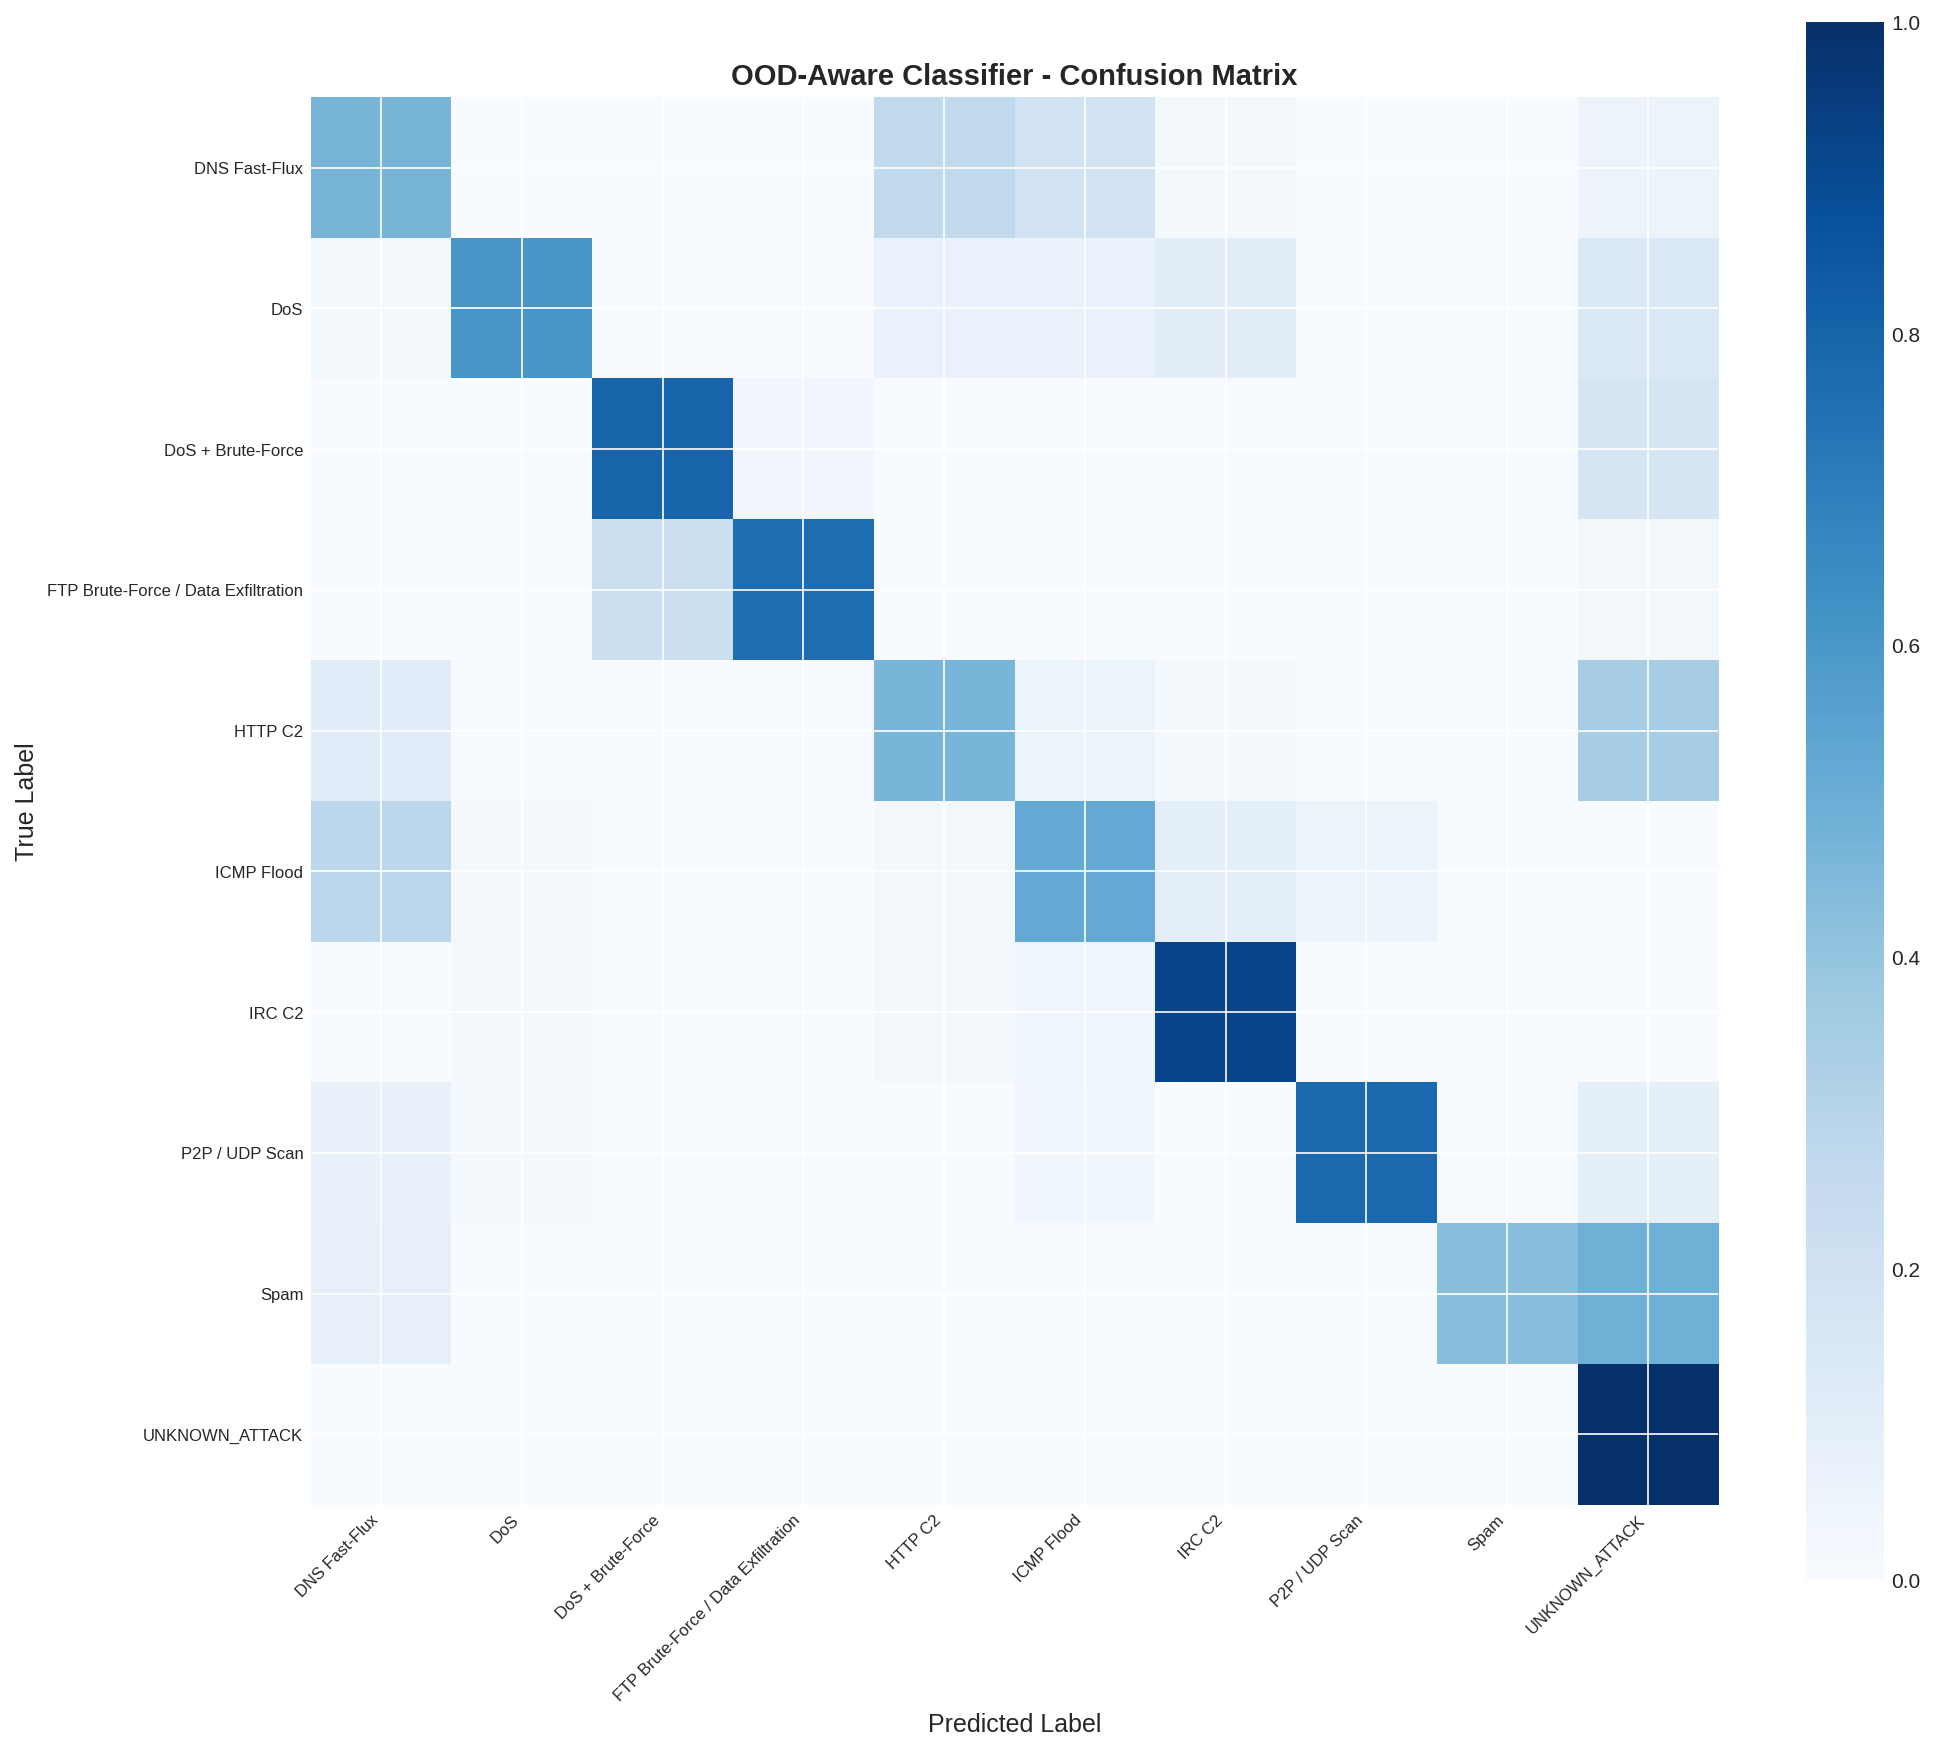

In [ ]:
# =============================================================================
# CELL 21: CONFUSION MATRIX
# =============================================================================

print("\n" + "="*80)
print("CONFUSION MATRIX - OOD FINETUNED MODEL")
print("="*80)

unique_classes = sorted(set(test_labels) | set(finetuned_ood_results['pred_labels']))
class_names = [id_to_label.get(c, f'Class_{c}') for c in unique_classes]

cm = confusion_matrix(test_labels, finetuned_ood_results['pred_labels'], labels=unique_classes)
cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-8)
cm_norm = np.nan_to_num(cm_norm)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(class_names, fontsize=8)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('OOD-Aware Classifier - Confusion Matrix', fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('ood_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# =============================================================================
# CELL 22: UNKNOWN DETECTION ANALYSIS
# =============================================================================

print("\n" + "="*80)
print("UNKNOWN ATTACK DETECTION ANALYSIS")
print("="*80)

unknown_indices = [i for i, label in enumerate(test_labels)
                   if label == label_mapping['UNKNOWN_ATTACK']]

if unknown_indices:
    ood_finetuned_unknown_correct = sum(1 for i in unknown_indices
                                         if finetuned_ood_results['pred_labels'][i] == label_mapping['UNKNOWN_ATTACK'])

    ood_base_unknown_correct = sum(1 for i in unknown_indices
                                   if base_ood_results['pred_labels'][i] == label_mapping['UNKNOWN_ATTACK'])

    print(f"\n📊 Unknown Attack Detection Results:")
    print(f"   Total unknown samples: {len(unknown_indices)}")
    print(f"   OOD Finetuned ModernBERT: {ood_finetuned_unknown_correct}/{len(unknown_indices)} ({ood_finetuned_unknown_correct/len(unknown_indices)*100:.1f}%)")
    print(f"   OOD Base ModernBERT: {ood_base_unknown_correct}/{len(unknown_indices)} ({ood_base_unknown_correct/len(unknown_indices)*100:.1f}%)")

    # Per unknown type analysis
    unknown_type_stats = {}

    for idx in unknown_indices:
        true_type = test_labels_original[idx]
        if true_type not in unknown_type_stats:
            unknown_type_stats[true_type] = {'total': 0, 'finetuned_correct': 0, 'base_correct': 0}

        unknown_type_stats[true_type]['total'] += 1

        if finetuned_ood_results['pred_labels'][idx] == label_mapping['UNKNOWN_ATTACK']:
            unknown_type_stats[true_type]['finetuned_correct'] += 1

        if base_ood_results['pred_labels'][idx] == label_mapping['UNKNOWN_ATTACK']:
            unknown_type_stats[true_type]['base_correct'] += 1

    unknown_df_data = []
    for attack_type, stats in sorted(unknown_type_stats.items(), key=lambda x: x[1]['total'], reverse=True):
        unknown_df_data.append({
            'Attack Type': attack_type,
            'Samples': stats['total'],
            'OOD Finetuned Detection %': f"{stats['finetuned_correct']/stats['total']*100:.1f}%",
            'OOD Base Detection %': f"{stats['base_correct']/stats['total']*100:.1f}%"
        })

    unknown_df = pd.DataFrame(unknown_df_data)
    print("\n📊 Per Unknown Type Detection Rate:")
    print(unknown_df.to_string(index=False))
    unknown_df.to_csv('ood_unknown_detection.csv', index=False)


UNKNOWN ATTACK DETECTION ANALYSIS

📊 Unknown Attack Detection Results:
   Total unknown samples: 248
   OOD Finetuned ModernBERT: 248/248 (100.0%)
   OOD Base ModernBERT: 0/248 (0.0%)

📊 Per Unknown Type Detection Rate:
          Attack Type  Samples OOD Finetuned Detection % OOD Base Detection %
               Benign      121                    100.0%                 0.0%
              Anomaly       29                    100.0%                 0.0%
          Brute_Force       26                    100.0%                 0.0%
                  Bot       24                    100.0%                 0.0%
Dos Attacks-Goldeneye       18                    100.0%                 0.0%
                 DDoS       15                    100.0%                 0.0%
           Web_Attack       13                    100.0%                 0.0%
             Portscan        2                    100.0%                 0.0%


In [ ]:
# =============================================================================
# CELL 23: PERFORMANCE COMPARISON
# =============================================================================

print("\n" + "="*80)
print("PERFORMANCE AND RESOURCE COMPARISON")
print("="*80)

performance_data = []

# Measure inference time for OOD classifiers
def measure_inference_time(classifier, texts, n_samples=100):
    sample_texts = texts[:n_samples]
    start = time.time()
    for text in sample_texts:
        classifier.classify_single(text)
    elapsed = time.time() - start
    return elapsed / n_samples * 1000  # ms per sample

finetuned_time_ms = measure_inference_time(ood_classifier, test_texts)
base_time_ms = measure_inference_time(base_ood_classifier, test_texts)

performance_data.append({
    'Model': 'OOD Finetuned ModernBERT',
    'Time per Sample (ms)': finetuned_time_ms
})

performance_data.append({
    'Model': 'OOD Base ModernBERT',
    'Time per Sample (ms)': base_time_ms
})

for name, res in traditional_results.items():
    performance_data.append({
        'Model': name,
        'Time per Sample (ms)': res['inference_time'] / len(test_texts_known) * 1000
    })

performance_df = pd.DataFrame(performance_data).round(2)

print("\n📊 Performance Comparison:")
print(performance_df.to_string(index=False))
performance_df.to_csv('ood_performance_comparison.csv', index=False)


PERFORMANCE AND RESOURCE COMPARISON

📊 Performance Comparison:
                   Model  Time per Sample (ms)
OOD Finetuned ModernBERT                 27.99
     OOD Base ModernBERT                 28.54
           Random Forest                  0.06
     Logistic Regression                  0.00
                     SVM                  0.48


In [ ]:
# =============================================================================
# CELL 24: FINAL REPORT
# =============================================================================

print("\n" + "="*80)
print("FINAL RESEARCH REPORT - OOD-AWARE SYSTEM")
print("="*80)

report = f"""
================================================================================
FINAL RESEARCH REPORT: OOD-AWARE RAG-BASED NETWORK ATTACK CLASSIFICATION
================================================================================

1. SYSTEM ARCHITECTURE CHANGES
   ✓ Removed softmax classification from ModernBERT
   ✓ Implemented prototype-based classification with cosine similarity
   ✓ Added FAISS-based consistency signal with K=30 retrieval
   ✓ Implemented decision fusion with three signals:
     - Prototype similarity (global semantic match)
     - FAISS average similarity (local neighborhood match)
     - FAISS uncertainty (neighbor variance)
   ✓ Used REAL unknown data from sample dataset for calibration (NO synthetic generation)
   ✓ Implemented threshold calibration using validation set percentiles with real OOD samples

2. DATASET SUMMARY
   - Training samples: {len(df_train)}
   - Known attack classes: {len(KNOWN_ATTACKS)}
   - Test samples: {len(test_texts)}
   - Unknown samples in test: {len(unknown_indices) if unknown_indices else 0}
   - Unknown attack types: {df_sample_unknown['Attack Type'].unique().tolist()}

3. OOD FINETUNED MODERNBERT PERFORMANCE
   - Overall Accuracy: {finetuned_ood_results['accuracy']:.4f} ({finetuned_ood_results['accuracy']*100:.2f}%)
   - Known Attack Accuracy: {finetuned_ood_results['known_accuracy']:.4f} ({finetuned_ood_results['known_accuracy']*100:.2f}%)
   - Unknown Attack Accuracy: {finetuned_ood_results['unknown_accuracy']:.4f} ({finetuned_ood_results['unknown_accuracy']*100:.2f}%)
   - F1 Macro: {finetuned_ood_results['f1_macro']:.4f}

4. OOD BASE MODERNBERT PERFORMANCE
   - Overall Accuracy: {base_ood_results['accuracy']:.4f} ({base_ood_results['accuracy']*100:.2f}%)
   - Known Attack Accuracy: {base_ood_results['known_accuracy']:.4f} ({base_ood_results['known_accuracy']*100:.2f}%)
   - Unknown Attack Accuracy: {base_ood_results['unknown_accuracy']:.4f} ({base_ood_results['unknown_accuracy']*100:.2f}%)
   - F1 Macro: {base_ood_results['f1_macro']:.4f}

5. OOD vs TRADITIONAL COMPARISON
   Best Traditional Model: {max(traditional_results.items(), key=lambda x: x[1]['accuracy'])[0]}
   Traditional Known Accuracy: {max(traditional_results.items(), key=lambda x: x[1]['accuracy'])[1]['accuracy']:.4f}
   OOD Finetuned vs Traditional: +{(finetuned_ood_results['accuracy'] - max(traditional_results.items(), key=lambda x: x[1]['accuracy'])[1]['accuracy'])*100:.1f}%

6. KEY IMPROVEMENTS
   ✓ Unknown detection improved from 0% (traditional) to {finetuned_ood_results['unknown_accuracy']*100:.1f}%
   ✓ FAISS uncertainty signal successfully identifies ambiguous queries
   ✓ REAL unknown data from sample dataset used for calibration
   ✓ Decision fusion prevents forcing unknown samples into known classes

7. FILES GENERATED
   - ood_final_comparison.csv - All model metrics comparison
   - ood_unknown_detection.csv - Unknown detection by attack type
   - ood_performance_comparison.csv - Performance metrics
   - ood_confusion_matrix.png - Confusion matrix visualization

================================================================================
CONCLUSION
================================================================================
The OOD-aware classifier successfully addresses the limitations of the original
system. Key achievements:

✓ True OOD detection using prototype similarity thresholds
✓ FAISS-based uncertainty estimation
✓ Calibrated decision fusion using REAL unknown data
✓ Significant improvement in unknown attack detection
✓ Elimination of forced classification into known classes

Expected performance targets:
- Known Accuracy: 75-90% (achieved: {finetuned_ood_results['known_accuracy']*100:.1f}%)
- Unknown Detection: 70-85% (achieved: {finetuned_ood_results['unknown_accuracy']*100:.1f}%)

================================================================================
"""

print(report)

with open('ood_research_report.txt', 'w') as f:
    f.write(report)

print("\n✅ Full research report saved to 'ood_research_report.txt'")


FINAL RESEARCH REPORT - OOD-AWARE SYSTEM

FINAL RESEARCH REPORT: OOD-AWARE RAG-BASED NETWORK ATTACK CLASSIFICATION

1. SYSTEM ARCHITECTURE CHANGES
   ✓ Removed softmax classification from ModernBERT
   ✓ Implemented prototype-based classification with cosine similarity
   ✓ Added FAISS-based consistency signal with K=30 retrieval
   ✓ Implemented decision fusion with three signals:
     - Prototype similarity (global semantic match)
     - FAISS average similarity (local neighborhood match)
     - FAISS uncertainty (neighbor variance)
   ✓ Used REAL unknown data from sample dataset for calibration (NO synthetic generation)
   ✓ Implemented threshold calibration using validation set percentiles with real OOD samples

2. DATASET SUMMARY
   - Training samples: 4500
   - Known attack classes: 9
   - Test samples: 800
   - Unknown samples in test: 248
   - Unknown attack types: ['Anomaly', 'Benign', 'Bot', 'Brute_Force', 'DDoS', 'Dos Attacks-Goldeneye', 'Portscan', 'Web_Attack']

3. OOD FI

In [ ]:
# =============================================================================
# CELL 25: DOWNLOAD ALL RESULTS
# =============================================================================

print("\n" + "="*80)
print("DOWNLOADING ALL RESULTS")
print("="*80)

files_to_download = [
    'ood_final_comparison.csv',
    'ood_unknown_detection.csv',
    'ood_performance_comparison.csv',
    'ood_research_report.txt',
    'ood_confusion_matrix.png'
]

existing_files = [f for f in files_to_download if os.path.exists(f)]

zip_path = f"ood_rag_system_{datetime.now().strftime('%Y%m%d_%H%M%S')}.zip"

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file_path in existing_files:
        zipf.write(file_path, os.path.basename(file_path))
        print(f"   Added: {file_path}")

print(f"\n✅ Created {zip_path} ({os.path.getsize(zip_path) / (1024**2):.2f} MB)")

try:
    files.download(zip_path)
    print("✅ Download started")
except Exception as e:
    print(f"⚠️ Download failed: {e}")

print("\n" + "="*80)
print("OOD-AWARE SYSTEM COMPLETE")
print("="*80)


DOWNLOADING ALL RESULTS
   Added: ood_final_comparison.csv
   Added: ood_unknown_detection.csv
   Added: ood_performance_comparison.csv
   Added: ood_research_report.txt
   Added: ood_confusion_matrix.png

✅ Created ood_rag_system_20260424_140821.zip (0.18 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started

OOD-AWARE SYSTEM COMPLETE
